# Variáveis linguísticas de saída e de entrada

Os valores de entrada são:
1. **Índice de massa corpórea (IMC)**
2. **Glicose no sangue (glicemia de jejum)**
3. **Colesterol total.**

Como saída:
- **risco de doença cardíacas**


Essas 4 variáveis (3 entradas e 1 saída) são as variáveis linguísticas. Usarei mais de uma tabela, pois temos 4 variáveis, com o inuito de mapear as regras e indicar os conjuntos fuzzy dos antecedentes e consequentes das regras.

OBS: Podem ser usados 3 tipos de funções de pertinência: **triangular**, **gaussiana** e função de **trapezoidal**.

---
# Interpretando Artigos e criando conjuntos

## Obesidade X Doença cardiovascular

### Informação para os conjuntos conforme em [SBCBM - obesidade](https://sbcbm.org.br/obesidade-atinge-mais-de-67-milhoes-de-pessoas-no-brasil-em-2022/)


- **Peso ideal**: $18.5 <= IMC <= 24.9$
- **Sobrepeso: $IMC > 25 Kg/m²$**

**Obesidade se o IMC for maior ou igual a 30 Kg/m2.** A classificação da obesidade é feita da seguinte forma:

- **Grau I:  $30 <= IMC <= 34,9$**;
- **Grau II: $35 <= IMC <= 39,9$**;
- **Grau III: (obesidade mórbida): $IMC >= 40$**.

###Informação para as regras

#### Segundo fonte [SBCBM - obesidade](https://sbcbm.org.br/obesidade-atinge-mais-de-67-milhoes-de-pessoas-no-brasil-em-2022/)

"**Indicação**

Os critérios previstos nas portarias 424 e 425 do Ministério da Saúde para realização da cirurgia bariátrica pelo SUS são Índice de Massa Corporal (IMC) de 40 Kg/m², com ou sem comorbidades, sem sucesso no tratamento clínico por no mínimo dois anos e que tenham seguido protocolos clínicos.

As portarias também permitem a indicação para cirurgia bariátrica de pacientes com IMC > 35 kg/m2 e comorbidades com alto risco cardiovascular, diabetes e/ou hipertensão arterial de difícil controle, apneia do sono, doenças articulares degenerativas ou outras que não tenham tido sucesso no tratamento clínico."

"As portarias também permitem a indicação para cirurgia bariátrica de pacientes com IMC > 35 kg/m² e comorbidades com alto risco cardiovascular,"

#### Segundo fonte [world-health-organization](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight?utm_source=chatgpt.com)

"Being overweight in childhood and adolescence affects children’s and adolescents’ immediate health and is associated with greater risk and earlier onset of various NCDs, such as type 2 diabetes and cardiovascular disease."

#### Segundo fonte [jamacardiology-fullarticle](https://jamanetwork.com/journals/jamacardiology/fullarticle/2673289?utm_source=chatgpt.com)

"Compared with normal weight, among middle-aged men and women, competing hazard ratios for incident CVD were 1.21 (95% CI, 1.14-1.28) and 1.32 (95% CI, 1.24-1.40), respectively, for overweight (BMI, 25.0-29.9), 1.67 (95% CI, 1.55-1.79) and 1.85 (95% CI, 1.72-1.99) for obesity (BMI, 30.0-39.9), and 3.14 (95% CI, 2.48-3.97) and 2.53 (95% CI, 2.20-2.91) for morbid obesity (BMI, ≥40.0). Higher BMI had the strongest association with incident heart failure among CVD subtypes."

Há uma progressão quase “monótona” do risco de problemas cardiácos conforme subimos de normal → sobrepeso → obesidade → obesidade mórbida.

## Glicemia de jejum X Doença cardiovascular

### Conjunto fuzzy


Anteriormente era utilizado hipoglicemia como uma classe, porém ao pesquisar percebi que hipoglicemia é afetado por vários fatores e ela não tem uma relação óbvia com problema cardiovascular, ou seja dizer que ela implica risco de problemas cardíacos baixo é totalmente errado, pois ela pode ser associada à diabetes entre outras comorbidades que implicam em doenças cardiovasculares.

No modelo fuzzy atual, as entradas são apenas IMC, glicemia de jejum e colesterol total. Não há informações sobre diagnóstico de diabetes, tipo de tratamento, função hepática ou renal, frequência de episódios hipoglicêmicos ou outras doenças de base. Nessas condições, a simples presença de glicemia < 70 mg/dL em jejum é ambígua e poderia levar a uma inferência errada de risco cardiovascular como dito. Por esse motivo, optou-se por excluir a hipoglicemia, como classe.

Em um sistema mais completo, que incorporasse o manejo da hipoglicemia como fator de risco cardiovascular, seria necessário incluir variáveis adicionais, tais como: diagnóstico e tempo de diabetes, função hepática e renal, histórico de episódios de hipoglicemia grave, uso de álcool e estado nutricional. Só com esse conjunto de informações seria possível construir uma base de regras fuzzy capaz de interpretar adequadamente a hipoglicemia no contexto do risco cardiovascular global.

- ~**Hipoglicemia:** A presença de glicemia de jejum < 70~
- **Normal:** Glicemia de jejum entre $(70<=G<=99)\ mg/dL$;
- **Pré-diebete:** Glicemia de jejum entre $(100 <= G <= 125)\ mg/dL$;
- **Diabete_moderada:** Glicemia de jejum $ G >= 126

## Colesterol total X Doença cardiovascular

Como a descrição sobre os níveis de colesterol no nav dasa não estava muito completo, utilizei uma fonte americana:

[Cholesterol, Total, Serum](https://pediatric.testcatalog.org/show/CHOL) que diz sobre o conjuntos que podemos criar para o colesterol:

"Interpretation
The National Lipid Association and the National Cholesterol Education Program (NCEP) have set the following guidelines for total cholesterol:



Desirable: $<200 mg/dL$

Borderline High: $200\ to\ 239 mg/dL$

High: $ ≥ 240 mg/dL$"

Para o colesterol total, os conjuntos fuzzy foram definidos a partir dos pontos de corte recomendados por diretrizes internacionais e nacionais.

As diretrizes do National Cholesterol Education Program (NCEP ATP III) e da National Lipid Association classificam o colesterol total em desejável (<200 mg/dL), limítrofe (200–239 mg/dL) e alto (≥240 mg/dL).


No Brasil, a Atualização da Diretriz Brasileira de Dislipidemias e Prevenção da Aterosclerose e documentos derivados da Sociedade Brasileira de Cardiologia tornaram as metas mais rígidas, considerando valores desejáveis de colesterol total abaixo de 190 mg/dL como dito no navdasa.


Neste trabalho, utilizarei esses limiares como base para a construção dos conjuntos fuzzy, ajustando o valor desejável para 190 mg/dL a fim de alinhar o modelo ao contexto brasileiro.

Ou seja definimos o conjunto:

- **Desejável:** $C < 190 mg/dL$
- **limítrofe:** $(190 <= C <= 239)mg/dL$
- **Alto:** $C >= 240mg/dL$

## Risco de doença cardiovascular

A escolha de cinco funções de pertinência para a variável de saída visa aumentar a resolução do sistema de inferência. Diferente de uma classificação ternária (Baixo/Médio/Alto), a inclusão das classes 'Muito Alto' e 'Extremo' permite que o modelo capture nuances sutis na gravidade do paciente, diferenciando casos de alerta (Alto) de casos críticos (Muito Alto) e de situações de urgência médica (Extremo). Isso garante uma superfície de decisão mais suave e contínua."

"A granularidade com 5 classes foi definida para alinhar o resultado do sistema com níveis distintos de intervenção clínica. A adição da classe 'Extremo' é crucial para isolar pacientes que apresentam saturação em múltiplos fatores de risco (comorbidades simultâneas), sugerindo uma condição patológica já instalada, enquanto 'Muito Alto' sugere risco iminente, mas potencialmente reversível com terapias agressivas."

Onde de 0 a 100%, optou-se por uma distribuição equidistante (0, 25, 50, 75, 100):

- Baixo risco (0 - 20);
- Médio risco (20 - 40);
- Alto risco (40 - 60);
- Risco muito alto (60 - 80);
- Risco extremo (80 - 100);

Será utilizado gaussianas para modelar a tanto as entradas quanto as saídas o ápice das gaussianas (µ(x) = 1) é:

- c_baixo      = 0
- c_medio      = 25
- c_alto       = 50
- c_muito_alto = 75
- c_extremo    = 100


---
# Criando as tabelas

Para a criação das tabelas estou considerando as informações tiradas das referências que em geral são artigos, por exemplo sabemos que Obesidade tem uma relação direta com doença cardíaca segundo [jamacardiology-fullarticle](https://jamanetwork.com/journals/jamacardiology/fullarticle/2673289?utm_source=chatgpt.com), então podemos dizer por exemplo que sobrepeso é risco médio.

Ao mesmo tempo, percebi que as outras 2 variáveis também possuem uma relação direta com risco de doença cardiovascular. Logo se sobrepeso, mas se colesterol normal e glicemia normal, portanto risco baixo.


A minha interpretação dos artigos foi que existe uma relação praticamente direta entre as 3 variáveis e a saída. Então a criação da tabela foi de certa forma simples

#### Legenda para interpretação das tabelas

**IMC:**
- PI = Peso ideal
- SP = Sobrepeso
- O1 = Obesidade grau 1
- O2 = Obesidade grau 2
- O3 = Obesidade grau 3

**Risco de doença cardiovascular (saída):**
- B = Risco baixo
- M = Risco médio
- A = Risco Alto
- MA = Risco muito alto
- E = RIsco extremo

**Glicemia:**
- N = Normal
- PRE = Pre diabete
- D = Diabete


## Tabela 1 – Colesterol Desejável (CD)

#### Risco quando C < 190 mg/dL:

| IMC \ Glicemia | N | PRE | D |
| -------------- | - | --- | --- |
| **PI**         | B | B   | M   |
| **SP**         | B | M   | M   |
| **O1**         | M | M   | A   |
| **O2**         | M | A   | A   |
| **O3**         | A | MA   | MA  |


## Tabela 2 – Colesterol Limítrofe (CL)

#### Risco quando 190 ≤ C ≤ 239 mg/dL:

| IMC \ Glicemia | N  | PRE | D |
| -------------- | -- | --- | --- |
| **PI**         | B  | M   | M   |
| **SP**         | M  | M   | A   |
| **O1**         | M  | A   | MA  |
| **O2**         | A  | MA  | MA  |
| **O3**         | MA | MA  | E   |


## Tabela 3 – Colesterol Alto (CA)
Risco quando C ≥ 240 mg/dL:

| IMC \ Glicemia | N  | PRE | D |
| -------------- | -- | --- | --- |
| **PI**         | M  | M   | A   |
| **SP**         | M  | A   | MA  |
| **O1**         | A  | MA  | MA  |
| **O2**         | MA | MA  | E   |
| **O3**         | MA | E   | E   |


---
# Código

### Instalação da biblioteca `scikit-fuzzy`

In [2]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.3 MB/s eta 0:00:00


## Montando o conjunto de Saída (risco de doença cardiovascular)

In [3]:
import skfuzzy as fuzz

In [4]:
import numpy as np

x_risco = np.linspace(0, 100, 1001)

baixo       = fuzz.gaussmf(x_risco, 10, 8)
medio       = fuzz.gaussmf(x_risco, 30, 8)
alto        = fuzz.gaussmf(x_risco, 50, 8)
muito_alto  = fuzz.gaussmf(x_risco, 70, 8)
extremo     = fuzz.smf(x_risco, 80, 90)  # sobe entre 80 e 90 e fica 1 daí pra frente


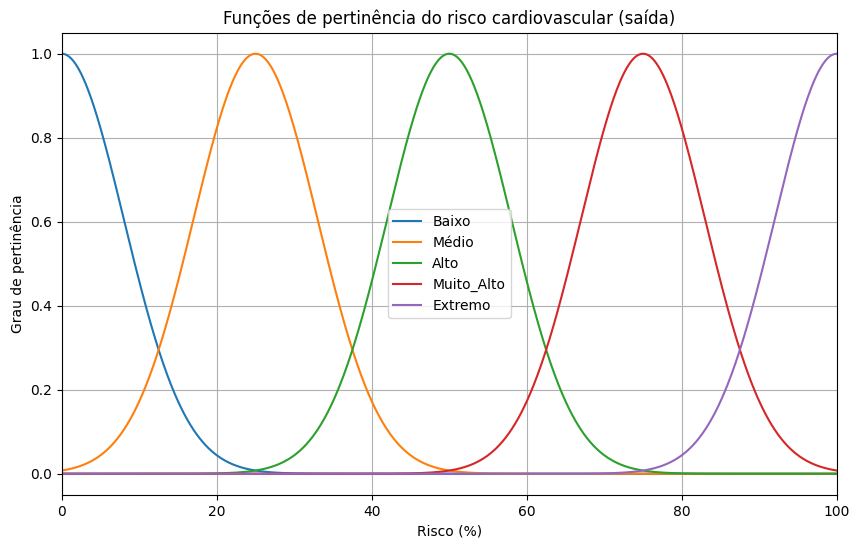

In [5]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Universo do risco (0 a 100%)
x_risco = np.linspace(0, 100, 1001)

# Mesmo sigma para todos
sigma = 8.0  # pode ajustar depois se quiser mais "larga" ou mais "estreita"

# Centros das gaussianas
c_baixo      = 0
c_medio      = 25
c_alto       = 50
c_muito_alto = 75
c_extremo    = 100

# Funções de pertinência (Baixo e Extremo viram "meia gaussiana" no intervalo 0–100)
baixo       = fuzz.gaussmf(x_risco, c_baixo,      sigma)
medio       = fuzz.gaussmf(x_risco, c_medio,      sigma)
alto        = fuzz.gaussmf(x_risco, c_alto,       sigma)
muito_alto  = fuzz.gaussmf(x_risco, c_muito_alto, sigma)
extremo     = fuzz.gaussmf(x_risco, c_extremo,    sigma)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_risco, baixo,      label='Baixo')
plt.plot(x_risco, medio,      label='Médio')
plt.plot(x_risco, alto,       label='Alto')
plt.plot(x_risco, muito_alto, label='Muito_Alto')
plt.plot(x_risco, extremo,    label='Extremo')

plt.title('Funções de pertinência do risco cardiovascular (saída)')
plt.xlabel('Risco (%)')
plt.ylabel('Grau de pertinência')
plt.ylim(-0.05, 1.05)
plt.xlim(0, 100)
plt.grid(True)
plt.legend()
plt.show()


## Montando Conjuntos das variáveis linguísticas de entrada

#### Como foi projetado as gaussianas das classes

Nas variáveis linguísticas segui exatamente como manda as regras que pesquisei sobre    

**O intuito é utilizar à risca as regras:**

**Glicemia:**
- **Normal:** Glicemia de jejum entre $(70<=G<=99)\ mg/dL$;
- **Pré-diebete:** Glicemia de jejum entre $(100 <= G <= 125)\ mg/dL$;
- **Diabete_moderada:** Glicemia de jejum $ G >= 126mg/dL$


**IMC**
- **Peso ideal**: $18.5 <= IMC <= 24.9$
- **Sobrepeso: $IMC > 25 Kg/m²$**
- **Grau I:  $30 <= IMC <= 34,9$**;
- **Grau II: $35 <= IMC <= 39,9$**;
- **Grau III: (obesidade mórbida): $IMC >= 40$**.

**Colesterol**
- **Desejável:** $C < 190 mg/dL$
- **limítrofe:** $(190 <= C <= 239)mg/dL$
- **Alto:** $C >= 240mg/dL$

Para criação de conjuntos criarei um "platô" que é basicamente uma função constante onde $µ(x) = 1$ no ápice da gaussiana na extrema direita (de maior valor) que definem as classes de cada conjunto. Isso é necessário, pois nenhuma das variáveis linguísticas de entrada na classe de maior valor possui um limite superior. Por exemplo Colesterol total alto: $C>=240mg/dL$, perceba que só é definido quando o colesterol total é alto e não quando ele deixa de ser alto e passa a ser outra classe. Isso me fez deduzir que qualquer colesterol extremo é automaticamente alto de $µ(x) = 1$, isso ficará muito claro nas funções de pertinências.

Outra estratégia utilizada para definir como a gaussiana se comportará (sua largura σ) nos conjuntos é que na interceção das classes o $µ(x) = 0.3$


Sabendo que a equação da Gaussiana é

$$f(x) = e^{-\frac{(x - c)^2}{2\sigma^2}}$$

<br>

Onde:
- c é a média do intervalo (centro)

- x é o ponto da borda (exemplo: 25, 30, 40 como em IMC)

- f(x) = 0.3

<br>

Logo,

$$0.3 = e^{-\frac{(x - c)^2}{2\sigma^2}}$$$$\ln(0.3) = -\frac{(x - c)^2}{2\sigma^2}$$$$2\sigma^2 = \frac{-(x - c)^2}{\ln(0.3)}$$$$\sigma = \frac{|x - c|}{\sqrt{-2 \ln(0.3)}}$$

<br>

Calculando a constante $\sqrt{-2 \ln(0.3)}$:
$\ln(0.3) \approx -1.2039$
$-2 \times -1.2039 \approx 2.4079$
$\sqrt{2.4079} \approx 1.551$

Na prática

$\sigma = \frac{\text{Distância da Média até a Borda}}{1.55}$

Exemplo:


- Intervalo: $18.5$ a $24.9$.

- Centro ($c$): $(18.5 + 24.9) / 2 = 21.7$.

- Borda Superior ($x$): $25$ (início do Sobrepeso).

- Distância: $25 - 21.7 = 3.3$.

- Sigma: $3.3 / 1.55 \approx \mathbf{2.12}$.


Isso tudo foi com o intuito de trazer uma transição suave entre as classes e um padrão nas trocas das classes

### IMC

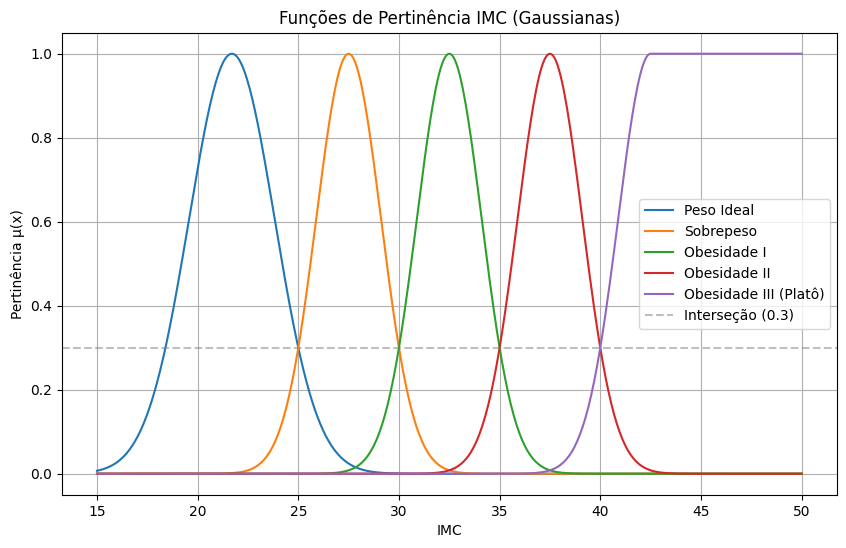

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, c, sigma):
    return np.exp(-((x - c)**2) / (2 * sigma**2))

def fuzzy_set(x, c, sigma, type='normal'):
    """
    type: 'normal' (gaussiana pura), 'left_shoulder' (platô esq), 'right_shoulder' (platô dir)
    """
    g = gaussian(x, c, sigma)
    if type == 'left_shoulder':
        # Se x for menor que o centro, é 1. Se maior, desce como gaussiana
        return np.where(x <= c, 1.0, g)
    elif type == 'right_shoulder':
        # Se x for maior que o centro, é 1. Se menor, sobe como gaussiana
        return np.where(x >= c, 1.0, g)
    else:
        return g

# Constante derivada de sqrt(-2 * ln(0.3))
K = 1.5518

# --- Configuração para IMC ---
# Definição dos Centros (médias) e Bordas para calcular o Sigma
# Peso Ideal (18.5 - 24.9) -> Centro ~21.7. Borda 25.
c_ideal = 21.7
dist_ideal = 25 - c_ideal # 3.3
sigma_ideal = dist_ideal / K

# Sobrepeso (25 - 29.9) -> Centro ~27.5. Borda 25 (ou 30).
c_sobre = 27.5
dist_sobre = 27.5 - 25 # 2.5
sigma_sobre = dist_sobre / K

# Grau I (30 - 34.9) -> Centro ~32.5. Borda 30.
c_g1 = 32.5
dist_g1 = 32.5 - 30 # 2.5
sigma_g1 = dist_g1 / K

# Grau II (35 - 39.9) -> Centro ~37.5. Borda 35.
c_g2 = 37.5
dist_g2 = 37.5 - 35 # 2.5
sigma_g2 = dist_g2 / K

# Grau III (>= 40) -> Platô Direito
# Queremos que em x=40, u=0.3. Vamos usar o mesmo sigma do Grau II para suavidade.
sigma_g3 = sigma_g2
# Calculamos onde deve ser o pico (centro) para que em 40 seja 0.3
c_g3 = 40 + (sigma_g3 * K)

# --- Geração do Gráfico ---
x = np.linspace(15, 50, 500)

y_ideal = fuzzy_set(x, c_ideal, sigma_ideal, 'normal') # Poderia ser left_shoulder se quisesse cobrir magreza
y_sobre = fuzzy_set(x, c_sobre, sigma_sobre, 'normal')
y_g1    = fuzzy_set(x, c_g1, sigma_g1, 'normal')
y_g2    = fuzzy_set(x, c_g2, sigma_g2, 'normal')
y_g3    = fuzzy_set(x, c_g3, sigma_g3, 'right_shoulder') # Platô!

plt.figure(figsize=(10, 6))
plt.plot(x, y_ideal, label='Peso Ideal')
plt.plot(x, y_sobre, label='Sobrepeso')
plt.plot(x, y_g1, label='Obesidade I')
plt.plot(x, y_g2, label='Obesidade II')
plt.plot(x, y_g3, label='Obesidade III (Platô)')

# Linha guia do 0.3
plt.axhline(0.3, color='gray', linestyle='--', alpha=0.5, label='Interseção (0.3)')
plt.grid(True)
plt.legend()
plt.title('Funções de Pertinência IMC (Gaussianas)')
plt.xlabel('IMC')
plt.ylabel('Pertinência µ(x)')
plt.show()

### Glicemia em jejum

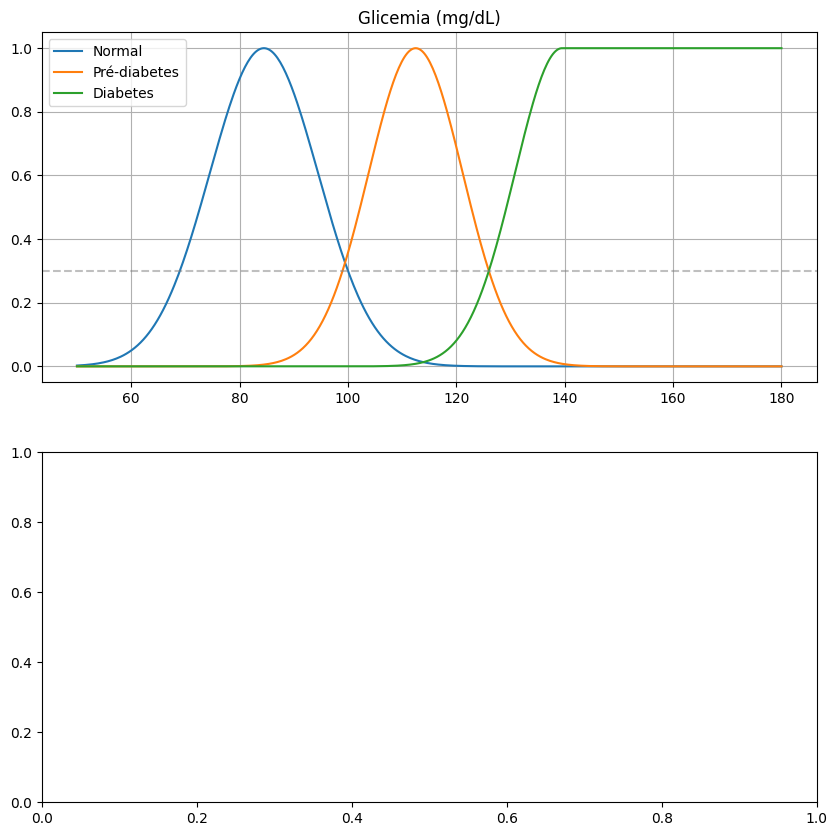

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, c, sigma):
    return np.exp(-((x - c)**2) / (2 * sigma**2))

def fuzzy_set(x, c, sigma, type='normal'):
    g = gaussian(x, c, sigma)
    if type == 'left_shoulder':
        return np.where(x <= c, 1.0, g)
    elif type == 'right_shoulder':
        return np.where(x >= c, 1.0, g)
    return g

# Constante de interseção em 0.3
K = 1.5518

# ==========================================
# 1. GLICEMIA
# ==========================================
x_gli = np.linspace(50, 180, 500)

# Normal (70-99) -> Centro 84.5
c_gn = 84.5
sigma_gn = 10.0

# Pré-Diabetes (100-125) -> Centro 112.5
c_gp = 112.5
sigma_gp = 8.7

# Diabetes (>= 126) -> Platô Direito
sigma_gd = 8.7 # Simetria com a anterior
c_gd = 126 + (sigma_gd * K) # ~139.5

y_gn = fuzzy_set(x_gli, c_gn, sigma_gn, 'normal')
y_gp = fuzzy_set(x_gli, c_gp, sigma_gp, 'normal')
y_gd = fuzzy_set(x_gli, c_gd, sigma_gd, 'right_shoulder')



# ==========================================
# PLOTAGEM
# ==========================================
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Plot Glicemia
axs[0].plot(x_gli, y_gn, label='Normal')
axs[0].plot(x_gli, y_gp, label='Pré-diabetes')
axs[0].plot(x_gli, y_gd, label='Diabetes')
axs[0].axhline(0.3, color='gray', linestyle='--', alpha=0.5)
axs[0].set_title('Glicemia (mg/dL)')
axs[0].legend()
axs[0].grid(True)


### Colesterol

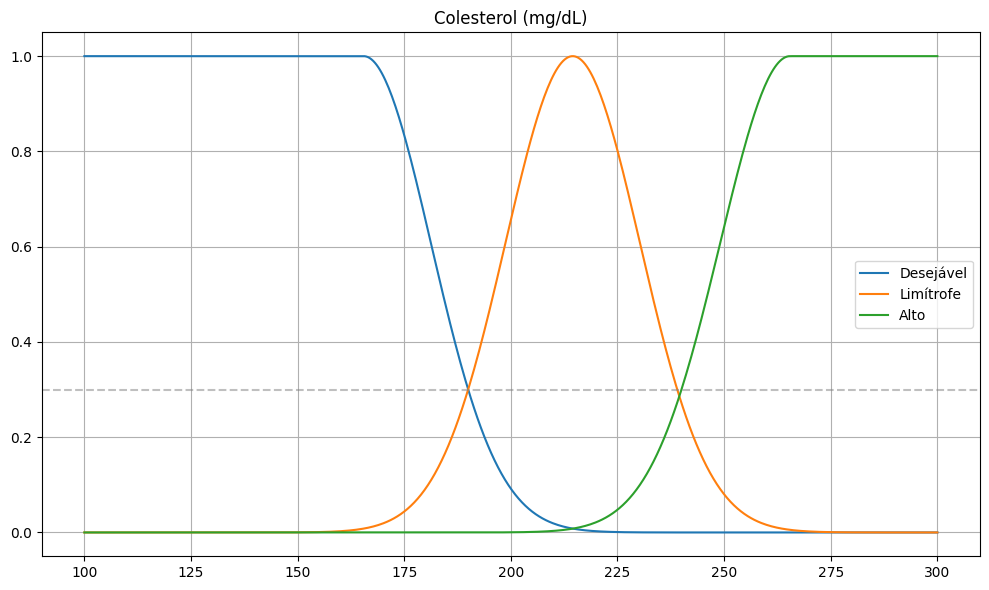

In [8]:

# ==========================================
# 2. COLESTEROL
# ==========================================
x_col = np.linspace(100, 300, 500)

# Limítrofe (190-239) -> Referência central
c_cl = 214.5
sigma_cl = 15.8

# Desejável (< 190) -> Platô Esquerdo
sigma_cd = 15.8 # Simetria
c_cd = 190 - (sigma_cd * K) # ~165.5

# Alto (>= 240) -> Platô Direito
sigma_ca = 16.4 # Ajustado para a borda de 240
c_ca = 240 + (sigma_ca * K) # ~265.5

y_cd = fuzzy_set(x_col, c_cd, sigma_cd, 'left_shoulder')
y_cl = fuzzy_set(x_col, c_cl, sigma_cl, 'normal')
y_ca = fuzzy_set(x_col, c_ca, sigma_ca, 'right_shoulder')

# Plot Colesterol
plt.figure(figsize=(10, 6))

plt.plot(x_col, y_cd, label='Desejável')
plt.plot(x_col, y_cl, label='Limítrofe')
plt.plot(x_col, y_ca, label='Alto')
plt.axhline(0.3, color='gray', linestyle='--', alpha=0.5)
plt.title('Colesterol (mg/dL)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Gráficos, Exemplo de população para teste da inferência e conclusões

### Teste de inferência com uma população de 10 pessoas e gráfico de como `Mamdani` resulta

ID  | PERFIL               | IMC   | GLI   | COL   | RISCO (%)  | CLASSIFICAÇÃO
--------------------------------------------------------------------------------
1   | Atleta Saudável      | 22    | 80    | 160   | 6.74%     | Baixo


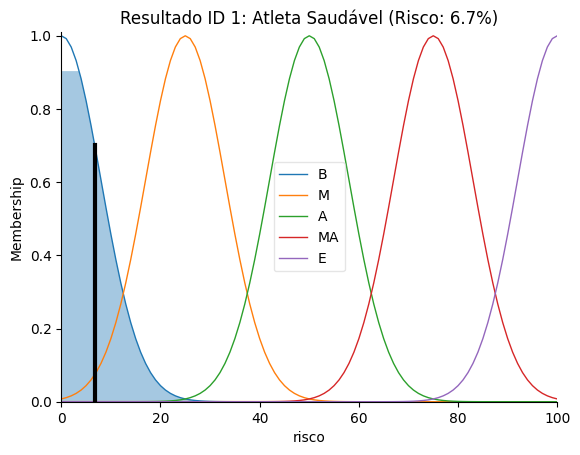

2   | Magro Diabético      | 20    | 140   | 170   | 25.03%     | Médio


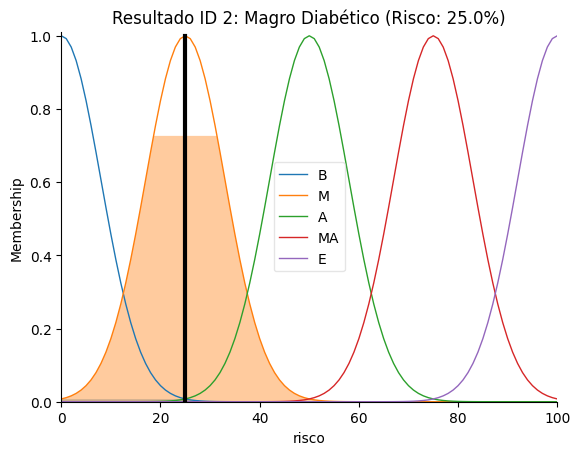

3   | Sobrepeso Leve       | 27    | 95    | 200   | 24.67%     | Médio


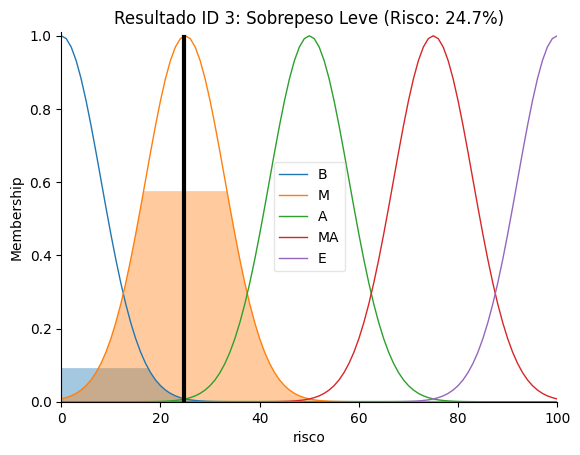

4   | Executivo Estressado | 28    | 110   | 250   | 47.47%     | Alto


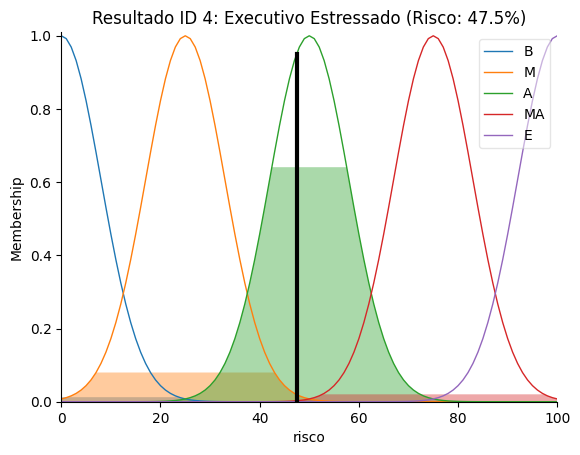

5   | Obesidade Inicial    | 31    | 90    | 210   | 27.05%     | Médio


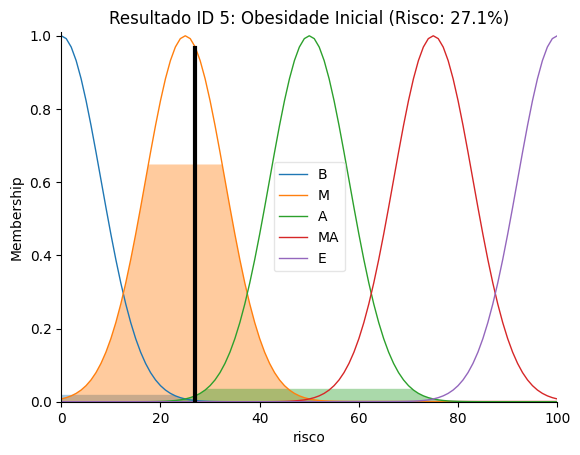

6   | Caso Complexo 1      | 33    | 115   | 245   | 67.26%     | Muito Alto


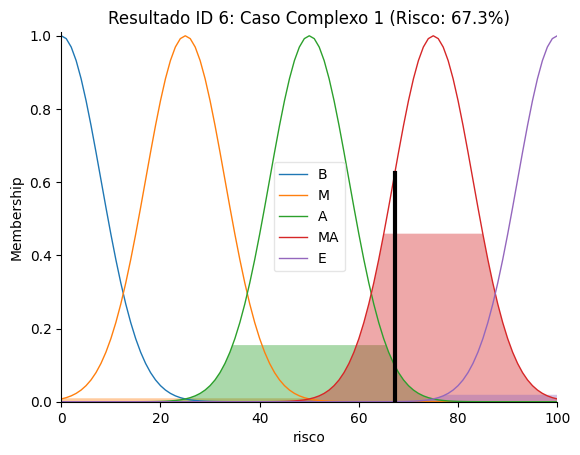

7   | Obesidade II         | 38    | 105   | 180   | 49.01%     | Alto


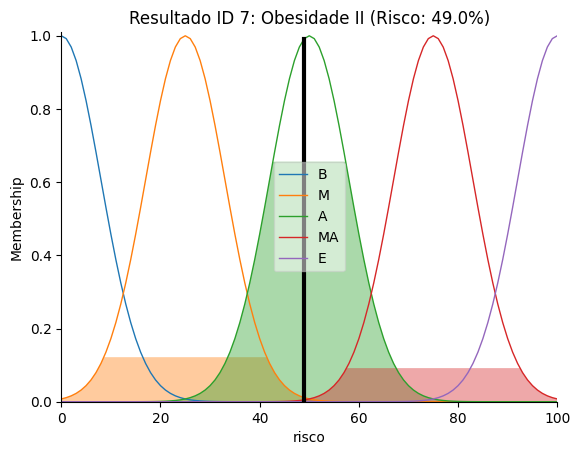

8   | Alto Risco           | 36    | 130   | 220   | 70.36%     | Muito Alto


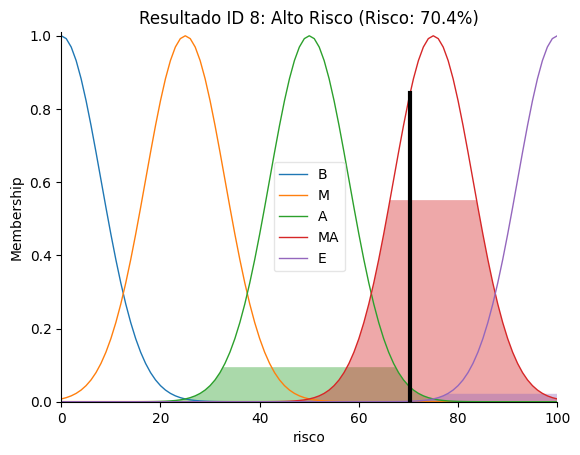

9   | Mórbida Controlada   | 42    | 90    | 185   | 56.32%     | Alto


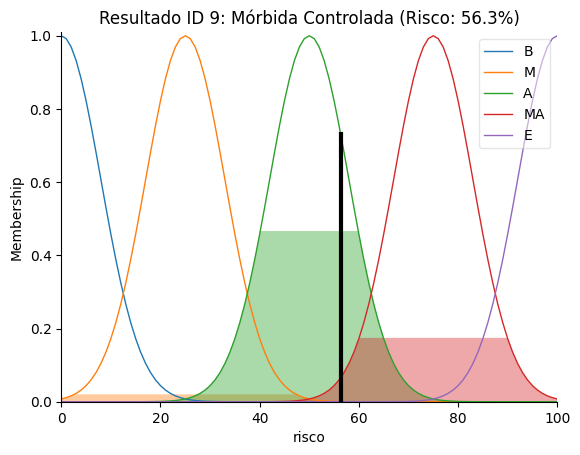

10  | Situação Extrema     | 45    | 150   | 280   | 93.60%     | Extremo


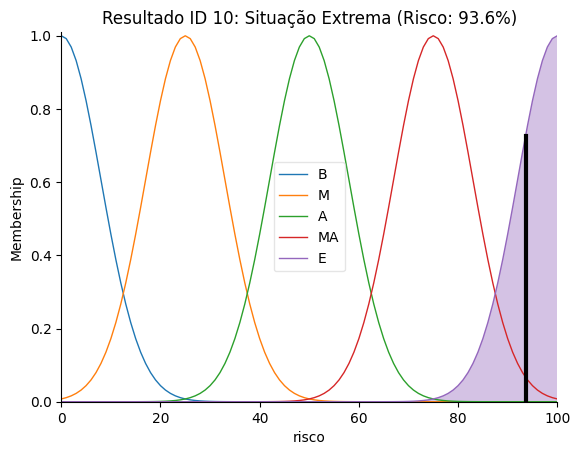

In [9]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNÇÕES AUXILIARES (Definição Matemática)
# ==========================================

def gaussian(x, c, sigma):
    return np.exp(-((x - c)**2) / (2 * sigma**2))

def fuzzy_set(x, c, sigma, type='normal'):
    """Gera arrays de pertinência com suporte a platôs (shoulders)"""
    g = gaussian(x, c, sigma)
    if type == 'left_shoulder':
        return np.where(x <= c, 1.0, g)
    elif type == 'right_shoulder':
        return np.where(x >= c, 1.0, g)
    return g

# Constante de interseção em 0.3
K = 1.5518

# ==========================================
# 2. DEFINIÇÃO DAS VARIÁVEIS (ANTECEDENTES E CONSEQUENTE)
# ==========================================

# Universos de discurso das variáveis
x_imc = np.arange(10, 55, 0.1)
x_gli = np.arange(40, 300, 1)
x_col = np.arange(100, 350, 1)
x_risco = np.arange(0, 101, 1)

# Criação dos objetos de controle
imc = ctrl.Antecedent(x_imc, 'imc')
glicemia = ctrl.Antecedent(x_gli, 'glicemia')
colesterol = ctrl.Antecedent(x_col, 'colesterol')
risco = ctrl.Consequent(x_risco, 'risco')

# --- Configuração do IMC (Sigmas calculados anteriormente) ---
# Peso Ideal (PI): Centro 21.7, Borda 25
imc['PI'] = fuzzy_set(x_imc, 21.7, (3.3/K), 'normal')
# Sobrepeso (SP): Centro 27.5, Borda 25
imc['SP'] = fuzzy_set(x_imc, 27.5, (2.5/K), 'normal')
# Grau I (O1): Centro 32.5, Borda 30
imc['O1'] = fuzzy_set(x_imc, 32.5, (2.5/K), 'normal')
# Grau II (O2): Centro 37.5, Borda 35
imc['O2'] = fuzzy_set(x_imc, 37.5, (2.5/K), 'normal')
# Grau III (O3): Platô, usando sigma do O2
s_o2 = 2.5/K
imc['O3'] = fuzzy_set(x_imc, 40 + (s_o2*K), s_o2, 'right_shoulder')

# --- Configuração da Glicemia ---
# Normal (N): Centro 84.5, Borda 100
glicemia['N'] = fuzzy_set(x_gli, 84.5, (15.5/K), 'normal')
# Pré-diabetes (PRE): Centro 112.5, Borda 126
glicemia['PRE'] = fuzzy_set(x_gli, 112.5, (13.5/K), 'normal')
# Diabetes (D): Platô
s_pre = 13.5/K
glicemia['D'] = fuzzy_set(x_gli, 126 + (s_pre*K), s_pre, 'right_shoulder')

# --- Configuração do Colesterol ---
# Limítrofe (CL) - Referência Central: Centro 214.5, Borda 190
s_cl = 24.5/K
colesterol['CL'] = fuzzy_set(x_col, 214.5, s_cl, 'normal')
# Desejável (CD): Platô Esquerdo
colesterol['CD'] = fuzzy_set(x_col, 190 - (s_cl*K), s_cl, 'left_shoulder')
# Alto (CA): Platô Direito
s_ca = 25.5/K
colesterol['CA'] = fuzzy_set(x_col, 240 + (s_ca*K), s_ca, 'right_shoulder')

# --- Configuração da Saída: RISCO (Conforme seu código) ---
sigma_r = 8.0
risco['B']  = fuzz.gaussmf(x_risco, 0, sigma_r)
risco['M']  = fuzz.gaussmf(x_risco, 25, sigma_r)
risco['A']  = fuzz.gaussmf(x_risco, 50, sigma_r)
risco['MA'] = fuzz.gaussmf(x_risco, 75, sigma_r)
risco['E']  = fuzz.gaussmf(x_risco, 100, sigma_r)

# Método de Defuzzificação (Centróide)
risco.defuzzification_method = 'centroid'

# ==========================================
# 3. BASE DE REGRAS (Mapeamento das Tabelas)
# ==========================================

rules = []

# Dicionário auxiliar para mapear strings das tabelas para os termos fuzzy
map_risk = {'B': risco['B'], 'M': risco['M'], 'A': risco['A'],
            'MA': risco['MA'], 'E': risco['E']}

# Tabela 1: Colesterol Desejável (CD)
# Matriz [IMC][Glicemia] -> [PI, SP, O1, O2, O3] x [N, PRE, D]
t1_res = [
    ['B', 'B', 'M'],  # PI
    ['B', 'M', 'M'],  # SP
    ['M', 'M', 'A'],  # O1
    ['M', 'A', 'A'],  # O2
    ['A', 'MA', 'MA'] # O3
]
imcs = ['PI', 'SP', 'O1', 'O2', 'O3']
glis = ['N', 'PRE', 'D']

for i, row_imc in enumerate(imcs):
    for j, col_gli in enumerate(glis):
        out = t1_res[i][j]
        # Regra: SE Colesterol é CD E IMC é X E Glicemia é Y ENTÃO Risco é Z
        rules.append(ctrl.Rule(colesterol['CD'] & imc[row_imc] & glicemia[col_gli], map_risk[out]))

# Tabela 2: Colesterol Limítrofe (CL)
t2_res = [
    ['B', 'M', 'M'],
    ['M', 'M', 'A'],
    ['M', 'A', 'MA'],
    ['A', 'MA', 'MA'],
    ['MA', 'MA', 'E']
]
for i, row_imc in enumerate(imcs):
    for j, col_gli in enumerate(glis):
        out = t2_res[i][j]
        rules.append(ctrl.Rule(colesterol['CL'] & imc[row_imc] & glicemia[col_gli], map_risk[out]))

# Tabela 3: Colesterol Alto (CA)
t3_res = [
    ['M', 'M', 'A'],
    ['M', 'A', 'MA'],
    ['A', 'MA', 'MA'],
    ['MA', 'MA', 'E'],
    ['MA', 'E', 'E']
]
for i, row_imc in enumerate(imcs):
    for j, col_gli in enumerate(glis):
        out = t3_res[i][j]
        rules.append(ctrl.Rule(colesterol['CA'] & imc[row_imc] & glicemia[col_gli], map_risk[out]))

# Criação do Sistema de Controle
cardio_ctrl = ctrl.ControlSystem(rules)
cardio_sim = ctrl.ControlSystemSimulation(cardio_ctrl)

# ==========================================
# 4. POPULAÇÃO DE TESTE E INFERÊNCIA
# ==========================================

# 10 Indivíduos com perfis variados para testar diferentes regras
populacao = [
    {'id': 1, 'perfil': 'Atleta Saudável', 'imc': 22, 'gli': 80, 'col': 160},   # Tudo ótimo
    {'id': 2, 'perfil': 'Magro Diabético', 'imc': 20, 'gli': 140, 'col': 170},  # PI, D, CD
    {'id': 3, 'perfil': 'Sobrepeso Leve',  'imc': 27, 'gli': 95, 'col': 200},   # SP, N, CL
    {'id': 4, 'perfil': 'Executivo Estressado', 'imc': 28, 'gli': 110, 'col': 250}, # SP, PRE, CA
    {'id': 5, 'perfil': 'Obesidade Inicial', 'imc': 31, 'gli': 90, 'col': 210}, # O1, N, CL
    {'id': 6, 'perfil': 'Caso Complexo 1', 'imc': 33, 'gli': 115, 'col': 245},  # O1, PRE, CA
    {'id': 7, 'perfil': 'Obesidade II',    'imc': 38, 'gli': 105, 'col': 180},  # O2, PRE, CD
    {'id': 8, 'perfil': 'Alto Risco',      'imc': 36, 'gli': 130, 'col': 220},  # O2, D, CL
    {'id': 9, 'perfil': 'Mórbida Controlada','imc': 42, 'gli': 90, 'col': 185}, # O3, N, CD
    {'id': 10,'perfil': 'Situação Extrema','imc': 45, 'gli': 150, 'col': 280}   # O3, D, CA
]

print(f"{'ID':<3} | {'PERFIL':<20} | {'IMC':<5} | {'GLI':<5} | {'COL':<5} | {'RISCO (%)':<10} | {'CLASSIFICAÇÃO'}")
print("-" * 80)

for p in populacao:
    # Input
    cardio_sim.input['imc'] = p['imc']
    cardio_sim.input['glicemia'] = p['gli']
    cardio_sim.input['colesterol'] = p['col']

    # Computar
    cardio_sim.compute()
    resultado = cardio_sim.output['risco']

    # Classificação Simples baseada no valor Crisp
    if resultado < 12.5: classe = "Baixo"
    elif resultado < 37.5: classe = "Médio"
    elif resultado < 62.5: classe = "Alto"
    elif resultado < 87.5: classe = "Muito Alto"
    else: classe = "Extremo"

    print(f"{p['id']:<3} | {p['perfil']:<20} | {p['imc']:<5} | {p['gli']:<5} | {p['col']:<5} | {resultado:.2f}%     | {classe}")

    # Plotar Gráfico Individual
    # Nota: Em um script real, plt.show() pausa a execução.
    # Aqui vamos gerar e você fecha a janela para ver o próximo.
    risco.view(sim=cardio_sim)
    plt.title(f"Resultado ID {p['id']}: {p['perfil']} (Risco: {resultado:.1f}%)")
    plt.show()

#### Tabela do Teste de inferência com uma população de 10 pessoas

In [10]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd  # Importante para a tabela final

# ==========================================
# 1. FUNÇÕES AUXILIARES (Definição Matemática)
# ==========================================

def gaussian(x, c, sigma):
    return np.exp(-((x - c)**2) / (2 * sigma**2))

def fuzzy_set(x, c, sigma, type='normal'):
    """Gera arrays de pertinência com suporte a platôs (shoulders)"""
    g = gaussian(x, c, sigma)
    if type == 'left_shoulder':
        return np.where(x <= c, 1.0, g)
    elif type == 'right_shoulder':
        return np.where(x >= c, 1.0, g)
    return g

# Constante de interseção em 0.3
K = 1.5518

# ==========================================
# 2. DEFINIÇÃO DAS VARIÁVEIS
# ==========================================

# Universos das variáveis
x_imc = np.arange(10, 55, 0.1)
x_gli = np.arange(40, 300, 1)
x_col = np.arange(100, 350, 1)
x_risco = np.arange(0, 101, 1)

# Criação dos objetos de controle
imc = ctrl.Antecedent(x_imc, 'imc')
glicemia = ctrl.Antecedent(x_gli, 'glicemia')
colesterol = ctrl.Antecedent(x_col, 'colesterol')
risco = ctrl.Consequent(x_risco, 'risco')

# --- Configuração do IMC ---
imc['PI'] = fuzzy_set(x_imc, 21.7, (3.3/K), 'normal')
imc['SP'] = fuzzy_set(x_imc, 27.5, (2.5/K), 'normal')
imc['O1'] = fuzzy_set(x_imc, 32.5, (2.5/K), 'normal')
imc['O2'] = fuzzy_set(x_imc, 37.5, (2.5/K), 'normal')
s_o2 = 2.5/K
imc['O3'] = fuzzy_set(x_imc, 40 + (s_o2*K), s_o2, 'right_shoulder')

# --- Configuração da Glicemia ---
glicemia['N'] = fuzzy_set(x_gli, 84.5, (15.5/K), 'normal')
glicemia['PRE'] = fuzzy_set(x_gli, 112.5, (13.5/K), 'normal')
s_pre = 13.5/K
glicemia['D'] = fuzzy_set(x_gli, 126 + (s_pre*K), s_pre, 'right_shoulder')

# --- Configuração do Colesterol ---
s_cl = 24.5/K
colesterol['CL'] = fuzzy_set(x_col, 214.5, s_cl, 'normal')
colesterol['CD'] = fuzzy_set(x_col, 190 - (s_cl*K), s_cl, 'left_shoulder')
s_ca = 25.5/K
colesterol['CA'] = fuzzy_set(x_col, 240 + (s_ca*K), s_ca, 'right_shoulder')

# --- Configuração da Saída: RISCO ---
sigma_r = 8.0
risco['B']  = fuzz.gaussmf(x_risco, 0, sigma_r)
risco['M']  = fuzz.gaussmf(x_risco, 25, sigma_r)
risco['A']  = fuzz.gaussmf(x_risco, 50, sigma_r)
risco['MA'] = fuzz.gaussmf(x_risco, 75, sigma_r)
risco['E']  = fuzz.gaussmf(x_risco, 100, sigma_r)

risco.defuzzification_method = 'centroid'

# ==========================================
# 3. BASE DE REGRAS
# ==========================================

rules = []
map_risk = {'B': risco['B'], 'M': risco['M'], 'A': risco['A'],
            'MA': risco['MA'], 'E': risco['E']}

# Tabela 1: Colesterol Desejável (CD)
t1_res = [['B', 'B', 'M'], ['B', 'M', 'M'], ['M', 'M', 'A'], ['M', 'A', 'A'], ['A', 'MA', 'MA']]
imcs = ['PI', 'SP', 'O1', 'O2', 'O3']
glis = ['N', 'PRE', 'D']

for i, row_imc in enumerate(imcs):
    for j, col_gli in enumerate(glis):
        rules.append(ctrl.Rule(colesterol['CD'] & imc[row_imc] & glicemia[col_gli], map_risk[t1_res[i][j]]))

# Tabela 2: Colesterol Limítrofe (CL)
t2_res = [['B', 'M', 'M'], ['M', 'M', 'A'], ['M', 'A', 'MA'], ['A', 'MA', 'MA'], ['MA', 'MA', 'E']]
for i, row_imc in enumerate(imcs):
    for j, col_gli in enumerate(glis):
        rules.append(ctrl.Rule(colesterol['CL'] & imc[row_imc] & glicemia[col_gli], map_risk[t2_res[i][j]]))

# Tabela 3: Colesterol Alto (CA)
t3_res = [['M', 'M', 'A'], ['M', 'A', 'MA'], ['A', 'MA', 'MA'], ['MA', 'MA', 'E'], ['MA', 'E', 'E']]
for i, row_imc in enumerate(imcs):
    for j, col_gli in enumerate(glis):
        rules.append(ctrl.Rule(colesterol['CA'] & imc[row_imc] & glicemia[col_gli], map_risk[t3_res[i][j]]))

cardio_ctrl = ctrl.ControlSystem(rules)
cardio_sim = ctrl.ControlSystemSimulation(cardio_ctrl)

# ==========================================
# 4. POPULAÇÃO DE TESTE E TABELA FINAL
# ==========================================

populacao = [
    {'id': 1, 'perfil': 'Atleta Saudável', 'imc': 22, 'gli': 80, 'col': 160},
    {'id': 2, 'perfil': 'Magro Diabético', 'imc': 20, 'gli': 140, 'col': 170},
    {'id': 3, 'perfil': 'Sobrepeso Leve',  'imc': 27, 'gli': 95, 'col': 200},
    {'id': 4, 'perfil': 'Executivo Estressado', 'imc': 28, 'gli': 110, 'col': 250},
    {'id': 5, 'perfil': 'Obesidade Inicial', 'imc': 31, 'gli': 90, 'col': 210},
    {'id': 6, 'perfil': 'Caso Complexo 1', 'imc': 33, 'gli': 115, 'col': 245},
    {'id': 7, 'perfil': 'Obesidade II',    'imc': 38, 'gli': 105, 'col': 180},
    {'id': 8, 'perfil': 'Alto Risco',      'imc': 36, 'gli': 130, 'col': 220},
    {'id': 9, 'perfil': 'Mórbida Controlada','imc': 42, 'gli': 90, 'col': 185},
    {'id': 10,'perfil': 'Situação Extrema','imc': 45, 'gli': 150, 'col': 280}
]

# Lista para armazenar os dados consolidados
resultados_consolidados = []

print("Processando indivíduos e gerando gráficos...")

for p in populacao:
    # Input
    cardio_sim.input['imc'] = p['imc']
    cardio_sim.input['glicemia'] = p['gli']
    cardio_sim.input['colesterol'] = p['col']

    # Computar
    cardio_sim.compute()
    resultado = cardio_sim.output['risco']

    # Classificação
    if resultado < 12.5: classe = "Baixo"
    elif resultado < 37.5: classe = "Médio"
    elif resultado < 62.5: classe = "Alto"
    elif resultado < 87.5: classe = "Muito Alto"
    else: classe = "Extremo"

    # Salvar na lista consolidada (arredondando valores para ficar bonito na tabela)
    resultados_consolidados.append({
        'ID': p['id'],
        'Perfil': p['perfil'],
        'IMC': p['imc'],
        'Glicemia': p['gli'],
        'Colesterol': p['col'],
        'Risco Calculado (%)': round(resultado, 2),
        'Classificação Final': classe
    })

    # Plotar Gráfico Individual (opcional: comente se quiser só a tabela)
    #risco.view(sim=cardio_sim)
    #plt.title(f"ID {p['id']}: {p['perfil']} (Risco: {resultado:.1f}%)")
    #plt.show()

# ==========================================
# 5. EXIBIÇÃO DA TABELA FINAL
# ==========================================

# Criando o DataFrame com Pandas
df_final = pd.DataFrame(resultados_consolidados)

# Ajustando alinhamento e visualização
print("\n" + "="*80)
print(f"{'TABELA CONSOLIDADA DE RESULTADOS DO SISTEMA FUZZY':^80}")
print("="*80)

# Opção 1: Print padrão do Pandas (simples e eficaz)
# print(df_final.to_string(index=False))

# Opção 2: Print formatado manualmente (para garantir beleza sem notebook)
# Define o formato das colunas
header = f"{'ID':<3} | {'PERFIL':<20} | {'IMC':<5} | {'GLI':<5} | {'COL':<5} | {'RISCO (%)':<10} | {'CLASSIFICAÇÃO'}"
print(header)
print("-" * len(header))

for index, row in df_final.iterrows():
    print(f"{row['ID']:<3} | {row['Perfil']:<20} | {row['IMC']:<5.1f} | {row['Glicemia']:<5.1f} | {row['Colesterol']:<5.1f} | {row['Risco Calculado (%)']:<10.2f} | {row['Classificação Final']}")

print("-" * len(header))
print("\nNota: Classificação baseada nos centróides das gaussianas de saída.")

Processando indivíduos e gerando gráficos...

               TABELA CONSOLIDADA DE RESULTADOS DO SISTEMA FUZZY                
ID  | PERFIL               | IMC   | GLI   | COL   | RISCO (%)  | CLASSIFICAÇÃO
-------------------------------------------------------------------------------
1   | Atleta Saudável      | 22.0  | 80.0  | 160.0 | 6.74       | Baixo
2   | Magro Diabético      | 20.0  | 140.0 | 170.0 | 25.03      | Médio
3   | Sobrepeso Leve       | 27.0  | 95.0  | 200.0 | 24.67      | Médio
4   | Executivo Estressado | 28.0  | 110.0 | 250.0 | 47.47      | Alto
5   | Obesidade Inicial    | 31.0  | 90.0  | 210.0 | 27.05      | Médio
6   | Caso Complexo 1      | 33.0  | 115.0 | 245.0 | 67.26      | Muito Alto
7   | Obesidade II         | 38.0  | 105.0 | 180.0 | 49.01      | Alto
8   | Alto Risco           | 36.0  | 130.0 | 220.0 | 70.36      | Muito Alto
9   | Mórbida Controlada   | 42.0  | 90.0  | 185.0 | 56.32      | Alto
10  | Situação Extrema     | 45.0  | 150.0 | 280.0 | 93.60

A tabela de resultados consolidados em conjunto com a avaliação do sistema mostrando o resultado do mamdani, evidenciam que o Sistema de Inferência Fuzzy desenvolvido é robusto e coerente. Ele não apresenta inversões lógicas (ex: alguém com piores exames tendo nota menor) e lida corretamente com os casos de borda e platôs (shoulders). A utilização das gaussianas permitiu uma transição suave entre os riscos, oferecendo uma avaliação mais rica e personalizada do que uma simples tabela rígida de pontuação. O sistema é, portanto, uma ferramenta válida de apoio à decisão para triagem de risco cardiovascular.

### Gráfico 3d + heatmap

No gráfico à seguir terei 2 cenários:
1. Fixando Glicemia ideal (90 de glicemia) - Variando Colesterol e IMC
    - Perceba o aumento do risco que vem ao decorrer do aumento do IMC ou Colesterol

2. Fixando IMC de um obeso de grau I (32 de IMC) - Variando Glicemia e Colesterol
    - Aqui ocorre um aumento significativo na forma de como cresce a função, pequenos aumento. É possível ver que a taxa de variação (derivadas parciais) é muito mais sensível à glicemia e colesterol, o que é esperado, pois uma pessoa nessa condição possui um risco significativamente maior de risco do que uma pessoa na situação ideal, o que reflete o nosso sistema fuzzy e a realidade

3. Fixando IMC de um obeso de grau III (42 de IMC) - Variando Glicemia e Colesterol
    - A taxa de variação tanto de Colesterol quanto de glicemia apresentam uma sensibilidade maior em consideração ao IMC de 32 e absurdamente maior do que para a pessoa de glicemia ideal. Isso também era o que esperávamos.


Calculando Cenário 1: IMC vs Colesterol (Glicemia Normal = 90)...


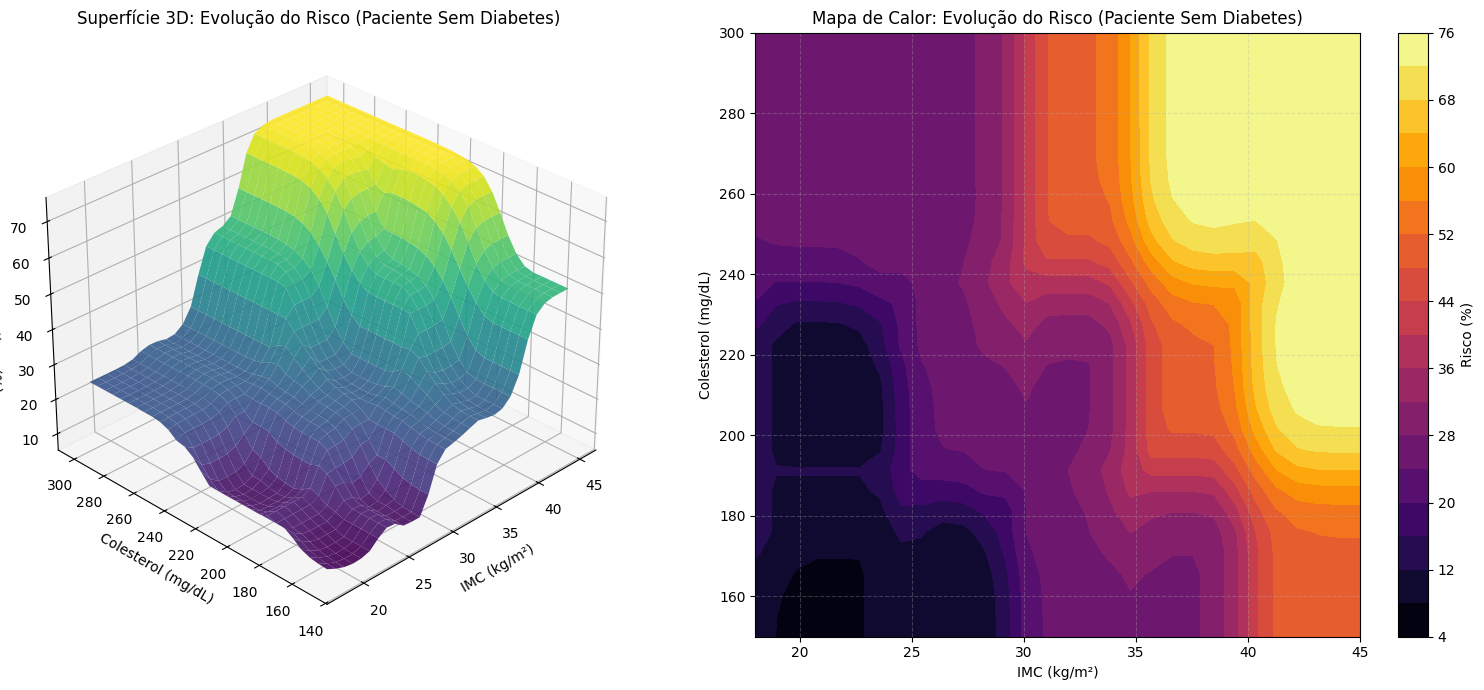

Calculando Cenário 2: Glicemia vs Colesterol (Paciente Obeso grau I - IMC = 32)...


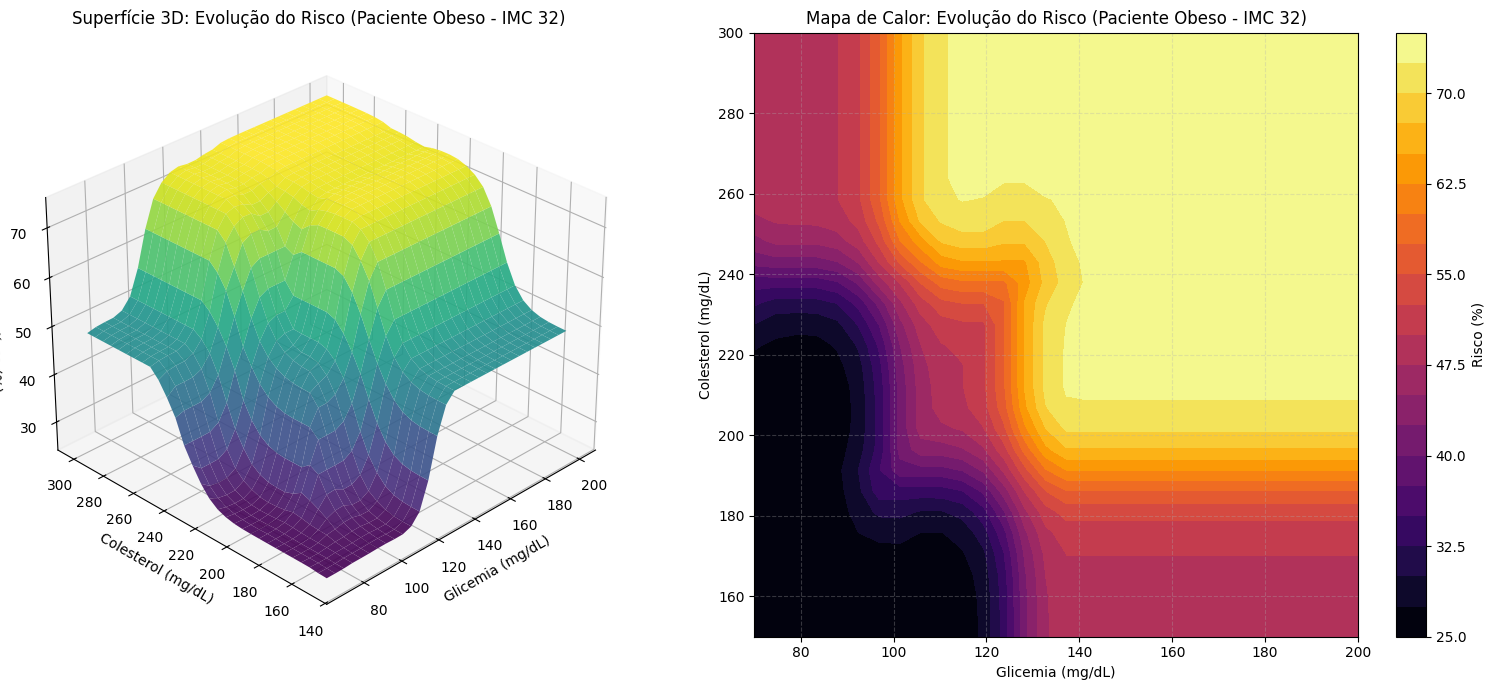

Calculando Cenário 3: Glicemia vs Colesterol (Paciente Obeso grau III - IMC = 42)...


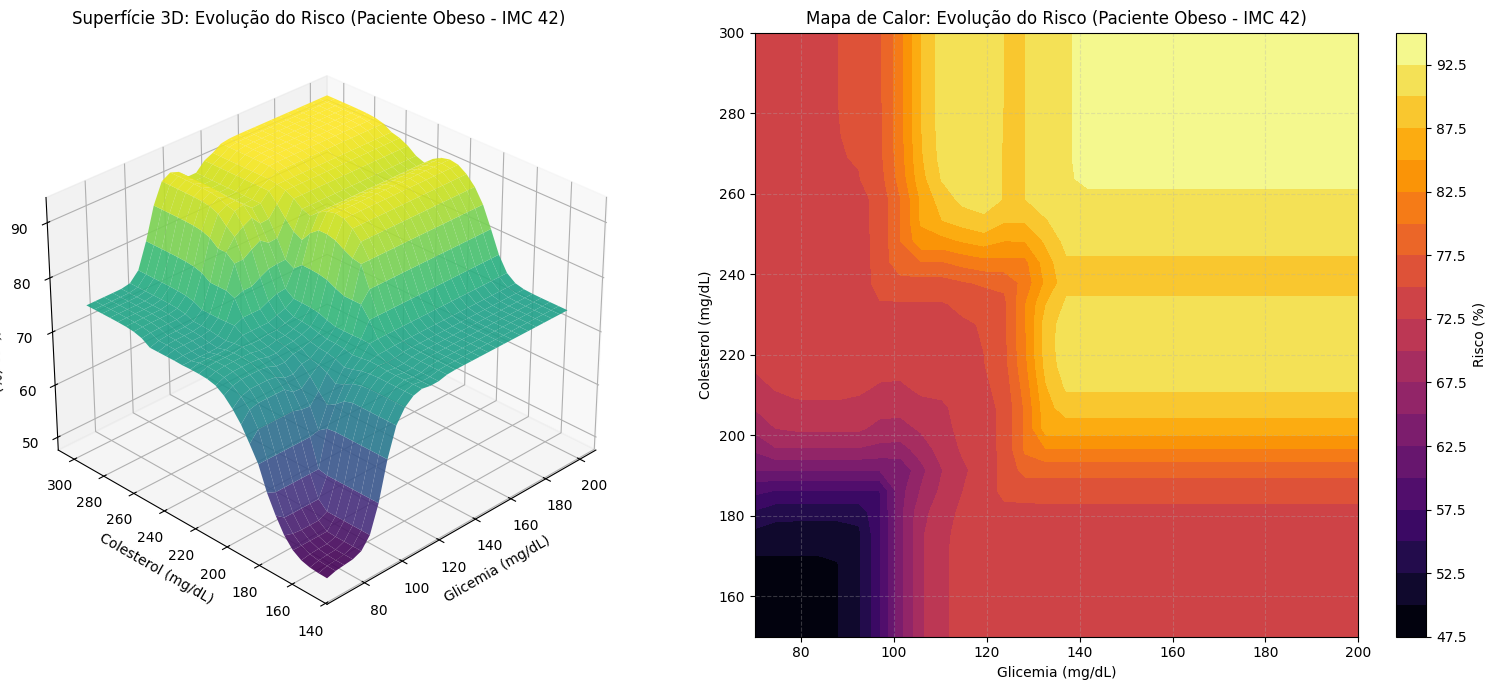

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def calcular_superficie_risco(simulacao, x_range, y_range, variavel_fixa, valor_fixo):
    """
    Gera a matriz Z (Risco) variando X e Y, mantendo a 3ª variável fixa.
    """
    Z = np.zeros((len(x_range), len(y_range)))

    for i, val_x in enumerate(x_range):
        for j, val_y in enumerate(y_range):
            # Configura as entradas baseadas no que estamos variando
            if variavel_fixa == 'glicemia':
                simulacao.input['imc'] = val_x
                simulacao.input['colesterol'] = val_y
                simulacao.input['glicemia'] = valor_fixo
            elif variavel_fixa == 'imc':
                simulacao.input['glicemia'] = val_x
                simulacao.input['colesterol'] = val_y
                simulacao.input['imc'] = valor_fixo
            elif variavel_fixa == 'colesterol':
                simulacao.input['imc'] = val_x
                simulacao.input['glicemia'] = val_y
                simulacao.input['colesterol'] = valor_fixo

            # Computa
            try:
                simulacao.compute()
                Z[i, j] = simulacao.output['risco']
            except:
                Z[i, j] = 0.0 # Caso nenhuma regra ative

    return Z

def plotar_cenario_3d_heatmap(X, Y, Z, label_x, label_y, titulo_cenario):
    """
    Plota o Gráfico 3D e o Heatmap lado a lado.
    """
    X_grid, Y_grid = np.meshgrid(X, Y)

    # Como o meshgrid inverte a indexação para plotagem, precisamos transpor o Z
    Z_plot = Z.T

    fig = plt.figure(figsize=(16, 7))

    # --- PLOT 3D ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax1.plot_surface(X_grid, Y_grid, Z_plot, cmap='viridis',
                            linewidth=0.2, antialiased=True, alpha=0.9)
    ax1.set_xlabel(label_x)
    ax1.set_ylabel(label_y)
    ax1.set_zlabel('Risco Cardíaco (%)')
    ax1.set_title(f'Superfície 3D: {titulo_cenario}')
    ax1.view_init(elev=30, azim=225) # Ângulo para ver melhor a subida

    # --- PLOT HEATMAP ---
    ax2 = fig.add_subplot(1, 2, 2)
    # Contourf cria curvas de nível suaves, pcolormesh cria blocos
    cp = ax2.contourf(X_grid, Y_grid, Z_plot, levels=20, cmap='inferno')
    fig.colorbar(cp, ax=ax2, label='Risco (%)')
    ax2.set_xlabel(label_x)
    ax2.set_ylabel(label_y)
    ax2.set_title(f'Mapa de Calor: {titulo_cenario}')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# CENÁRIO 1: O Efeito do Estilo de Vida (Sem Diabetes)
# Variáveis: IMC vs Colesterol
# Fixo: Glicemia = 90 (Normal)
# ==========================================

# Definindo os intervalos para visualização (reduzidos para processar rápido)
range_imc = np.linspace(18, 45, 30)       # Do magro à obesidade mórbida
range_col = np.linspace(150, 300, 30)     # Do saudável ao colesterol altíssimo

print("Calculando Cenário 1: IMC vs Colesterol (Glicemia Normal = 90)...")
Z_cenario1 = calcular_superficie_risco(cardio_sim, range_imc, range_col,
                                       variavel_fixa='glicemia', valor_fixo=90)

plotar_cenario_3d_heatmap(range_imc, range_col, Z_cenario1,
                          'IMC (kg/m²)', 'Colesterol (mg/dL)',
                          'Evolução do Risco (Paciente Sem Diabetes)')


# ==========================================
# CENÁRIO 2: A Zona de Perigo Metabólico
# Variáveis: Glicemia vs Colesterol
# Fixo: IMC = 32 (Obesidade Grau I)
# ==========================================

range_gli = np.linspace(70, 200, 30)      # Normal até Diabetes severa
range_col = np.linspace(150, 300, 30)

print("Calculando Cenário 2: Glicemia vs Colesterol (Paciente Obeso grau I - IMC = 32)...")
Z_cenario2 = calcular_superficie_risco(cardio_sim, range_gli, range_col,
                                       variavel_fixa='imc', valor_fixo=32)

plotar_cenario_3d_heatmap(range_gli, range_col, Z_cenario2,
                          'Glicemia (mg/dL)', 'Colesterol (mg/dL)',
                          'Evolução do Risco (Paciente Obeso - IMC 32)')

# ==========================================
# CENÁRIO 3: A Zona de Perigo Metabólico
# Variáveis: Glicemia vs Colesterol
# Fixo: IMC = 42 (Obesidade Grau III)
# ==========================================
range_gli = np.linspace(70, 200, 30)      # Normal até Diabetes severa
range_col = np.linspace(150, 300, 30)

print("Calculando Cenário 3: Glicemia vs Colesterol (Paciente Obeso grau III - IMC = 42)...")
Z_cenario2 = calcular_superficie_risco(cardio_sim, range_gli, range_col,
                                       variavel_fixa='imc', valor_fixo=42)

plotar_cenario_3d_heatmap(range_gli, range_col, Z_cenario2,
                          'Glicemia (mg/dL)', 'Colesterol (mg/dL)',
                          'Evolução do Risco (Paciente Obeso - IMC 42)')

O intuito desse gráfico é explicar como que para um cenário ocorre a evolução da "%" do risco de doença cardiovascular. Perceba que é bem compatível com a tabela, ao decorrer da piora de IMC ou glicemia ou colesterol total, temos um crescimento de certa forma uniforme do risco, isso é coerente também com o que foi pesquisado e concluído dos artigos retirados na referência sobre as variáveis linguísticas de entrada definida e o risco. Note também que se pioramos a situação do indivíduo o gráfico de heatmap e 3d que aparece é um com uma variação mais rápida.

---
# Referências

Algumas outras referências foram usadas também, isso para poder ajudar nas regras e nos conjuntos

**Obesidade X Doença cardiovascular**

* [SBCBM - obesidade](https://sbcbm.org.br/obesidade-atinge-mais-de-67-milhoes-de-pessoas-no-brasil-em-2022/)

* [world-health-organization](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight?utm_source=chatgpt.com)

* [jamacardiology-fullarticle](https://jamanetwork.com/journals/jamacardiology/fullarticle/2673289?utm_source=chatgpt.com)


<br>

**Glicemia de jejum X Doença cardiovascular**

* [diabete-journal](https://diabetesjournals.org/care/article/47/Supplement_1/S20/153954/2-Diagnosis-and-Classification-of-Diabetes)

* [tuasaude-glicemia-de-jejum](https://www.tuasaude.com/glicemia-de-jejum/)

* [navdasa-diabetes](http://nav.dasa.com.br/blog/tudo-sobre-diabetes)

<br>

**Colesterol total**

* [Cholesterol, Total, Serum](https://pediatric.testcatalog.org/show/CHOL)

* [navdasa-fatoes-de-risco](https://dasa.com.br/blog/saude/saude-do-coracao-e-os-fatores-de-risco-para-doencas-cardiovasculares/)